# Part I - Ford GoBike System Data
## by Belal Nwiran

## Introduction

> This dataset includes information about individual rides made in a bike-sharing system covering the greater San Francisco Bay Area in February 2019. Each row represents a single trip, and includes the trip's start and end time and location, the bike used, and some (optional, self-reported) information about the rider: user type, birth year, gender, and whether they are enrolled in the "bike share for all" affordability program.

Questions I want to explore in this analysis:

1. How long do trips typically last, and how does trip duration vary?
2. Who is using the system — what does the age, gender, and user-type mix look like?
3. When do people ride — what do daily and weekly usage patterns look like, and do they differ between casual (`Customer`) and regular (`Subscriber`) users?
4. Does rider behavior (trip duration, time of day) differ between `Subscriber` and `Customer` user types, and between genders?
5. Which stations are busiest, and does that give any hint about *why* people are using the service (commuting vs. leisure)?

## Preliminary Wrangling

In [32]:
# import all packages and set plots to be embedded inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

In [33]:
rides_df = pd.read_csv('201902-fordgobike-tripdata.csv')

### Dataset structure

In [34]:
print(rides_df.shape)
print(rides_df.info())

(183412, 16)
<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  str    
 2   end_time                 183412 non-null  str    
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  str    
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  str    
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  str    
 13  member_birth_year        175147 non-null  float64
 14  me

In [35]:
rides_df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [36]:
print(f"Number of duplicated rows: {rides_df.duplicated().sum()}")
print("Number of missing values per column:")
print(rides_df.isnull().sum())

Number of duplicated rows: 0
Number of missing values per column:
duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64


### What is the structure of your dataset?

> The dataset has **183,412** ride observations with 16 features: 3 features describing the ride's timing (`start_time`, `end_time`, `duration_sec`), 4 features describing the start station (`start_station_id`, `start_station_name`, `start_station_latitude`, `start_station_longitude`), 4 features describing the end station (`end_station_id`, `end_station_name`, `end_station_latitude`, `end_station_longitude`), plus `bike_id`, `user_type`, `member_birth_year`, `member_gender`, and `bike_share_for_all_trip`. Several columns have the wrong dtype for analysis: `start_time`/`end_time` are stored as strings rather than datetimes, and `member_birth_year` is stored as a float rather than an integer. `start_station_id`/`name`, `end_station_id`/`name`, `member_birth_year`, and `member_gender` all have a small number of missing values (197 and 8,265 rows respectively). There are no duplicated rows.

### What is/are the main feature(s) of interest in your dataset?

> The main features of interest are `duration_sec`, `start_time` (and the hour/day-of-week derived from it), and `user_type`. I'm most interested in understanding how long trips take and when they happen, and whether that differs by the kind of user taking the trip.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> `member_birth_year` (converted to `age`) and `member_gender` should help explain *who* is riding and whether that relates to duration or timing. `start_station_name`/location can help distinguish commute-oriented usage (e.g., trips starting near transit stations) from leisure usage, and `bike_share_for_all_trip` may correlate with `user_type` and trip patterns as well.

#### Fixing feature data types and engineering useful features

In [37]:
cleaned_rides_df = rides_df.copy()

# fix data types
cleaned_rides_df['start_time'] = pd.to_datetime(cleaned_rides_df['start_time'])
cleaned_rides_df['end_time'] = pd.to_datetime(cleaned_rides_df['end_time'])
cleaned_rides_df['user_type'] = cleaned_rides_df['user_type'].astype('category')
cleaned_rides_df['member_gender'] = cleaned_rides_df['member_gender'].astype('category')
cleaned_rides_df['bike_share_for_all_trip'] = cleaned_rides_df['bike_share_for_all_trip'].astype('category')

In [38]:
# engineer features that will support the investigation
cleaned_rides_df['duration_min'] = cleaned_rides_df['duration_sec'] / 60
cleaned_rides_df['age'] = 2019 - cleaned_rides_df['member_birth_year']
cleaned_rides_df['start_hour'] = cleaned_rides_df['start_time'].dt.hour
cleaned_rides_df['start_dow'] = cleaned_rides_df['start_time'].dt.day_name()

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cleaned_rides_df['start_dow'] = pd.Categorical(cleaned_rides_df['start_dow'], categories=dow_order, ordered=True)
cleaned_rides_df['is_weekend'] = cleaned_rides_df['start_dow'].isin(['Saturday', 'Sunday']).map({True: 'Weekend', False: 'Weekday'})

In [39]:
cleaned_rides_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             183412 non-null  int64         
 1   start_time               183412 non-null  datetime64[us]
 2   end_time                 183412 non-null  datetime64[us]
 3   start_station_id         183215 non-null  float64       
 4   start_station_name       183215 non-null  str           
 5   start_station_latitude   183412 non-null  float64       
 6   start_station_longitude  183412 non-null  float64       
 7   end_station_id           183215 non-null  float64       
 8   end_station_name         183215 non-null  str           
 9   end_station_latitude     183412 non-null  float64       
 10  end_station_longitude    183412 non-null  float64       
 11  bike_id                  183412 non-null  int64         
 12  user_type                18

In [40]:
# member_birth_year has some clearly invalid entries: ages up to 141 years old.
print(f"Number of riders older than 80: {(cleaned_rides_df['age'] > 80).sum()}")
cleaned_rides_df['age'].describe()

Number of riders older than 80: 192


count    175147.000000
mean         34.193563
std          10.116689
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max         141.000000
Name: age, dtype: float64

In [41]:
# drop rows with implausible ages (data entry errors); keep missing ages as-is (NaN),
# since those are a separate, legitimate "not reported" case rather than bad data
cleaned_rides_df = cleaned_rides_df[(cleaned_rides_df['age'].isnull()) | (cleaned_rides_df['age'] <= 80)]
print(cleaned_rides_df.shape)
cleaned_rides_df['age'].describe()

(183220, 21)


count    174955.000000
mean         34.121997
std           9.875893
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max          80.000000
Name: age, dtype: float64

In [42]:
# Saving cleaned data to a new CSV file for later use
cleaned_rides_df.to_csv('201902-fordgobike-tripdata-cleaned.csv', index=False)

## Univariate Exploration

> In this section I look at the distributions of individual variables of interest, starting with trip duration and rider age, then the categorical breakdowns (user type, day of week, gender, bike-share-for-all enrollment).

**Question:** How long do trips usually last?

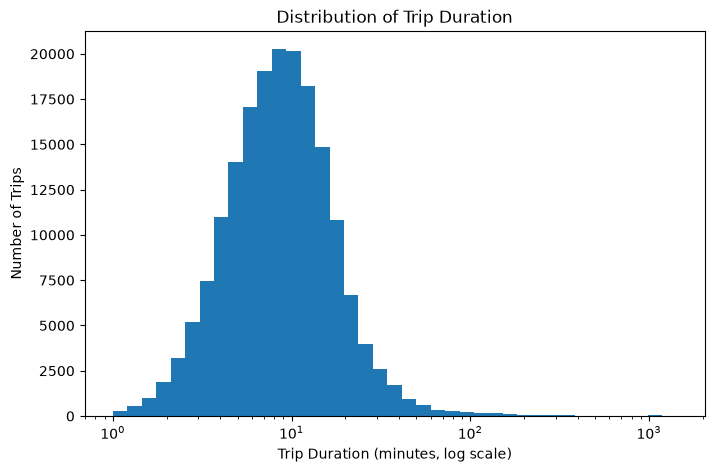

In [43]:
# duration is heavily right-skewed (mean 12.1 min, but a max of ~1424 min), so a log-scaled
# x-axis is needed to see the shape of the bulk of the distribution clearly
bins = 10 ** np.linspace(0, np.log10(cleaned_rides_df['duration_min'].max()), 40)
ax = cleaned_rides_df['duration_min'].plot.hist(bins=bins, figsize=(8, 5))
ax.set_xscale('log')
ax.set_xlabel('Trip Duration (minutes, log scale)')
ax.set_ylabel('Number of Trips')
ax.set_title('Distribution of Trip Duration');

**Observation:** The distribution of trip duration is unimodal and roughly log-normal, peaking around 8-10 minutes, with a long right tail out past 100 minutes. This confirms most trips are short, practical point-to-point rides rather than extended leisure rides, and justifies using a log scale for duration in later plots to avoid the long tail squashing everything else.

**Question:** How old are the members taking these trips?

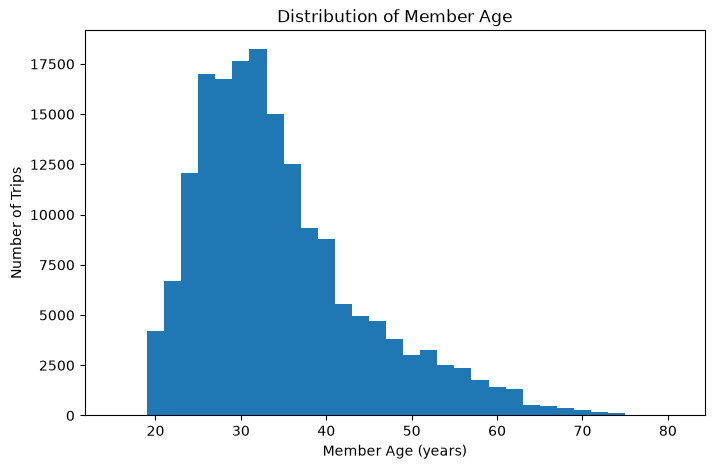

In [44]:
ax = cleaned_rides_df['age'].plot.hist(bins=np.arange(15, 82, 2), figsize=(8, 5))
ax.set_xlabel('Member Age (years)')
ax.set_ylabel('Number of Trips')
ax.set_title('Distribution of Member Age');

**Observation:** Member age is right-skewed with a peak in the late-20s to mid-30s (median 32), tapering off steadily into older age groups. This matches an expectation that bike-share is disproportionately used by young/working-age adults.

**Question:** What's the split between casual (`Customer`) and regular (`Subscriber`) riders?

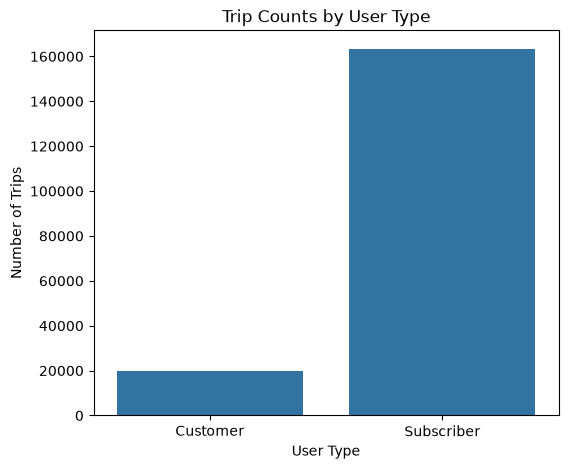

In [45]:
plt.figure(figsize=(6, 5))
sns.countplot(data=cleaned_rides_df, x='user_type', color=sns.color_palette()[0])
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.title('Trip Counts by User Type');

In [46]:
cleaned_rides_df['user_type'].value_counts(normalize=True)

user_type
Subscriber    0.891611
Customer      0.108389
Name: proportion, dtype: float64

**Observation:** The large majority of trips (about 89%) are taken by `Subscriber`s (regular, likely commute-oriented members), with only about 11% from one-off `Customer`s. This suggests the system's core usage is habitual rather than tourist/casual.

**Question:** Does ridership vary by day of the week?

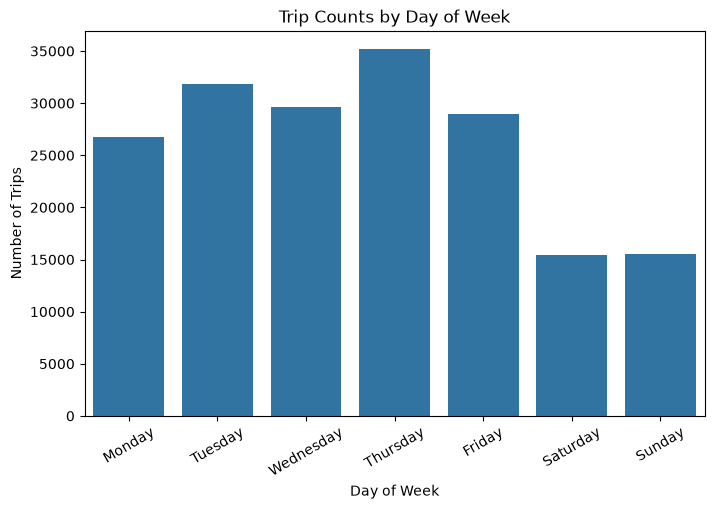

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(data=cleaned_rides_df, x='start_dow', color=sns.color_palette()[0])
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.title('Trip Counts by Day of Week')
plt.xticks(rotation=30);

**Observation:** Ridership is noticeably higher on weekdays (peaking mid-week on Tuesday-Thursday) and drops substantially on Saturday and Sunday — roughly half the weekday volume. This is an early signal that commuting, not weekend leisure, drives most trips.

**Question:** What's the gender breakdown of members (where reported)?

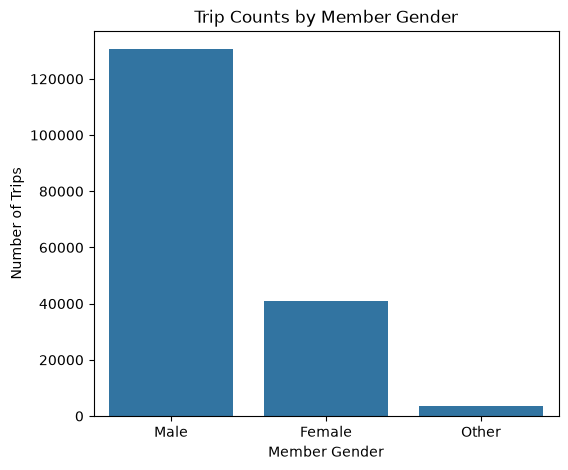

In [48]:
plt.figure(figsize=(6, 5))
gender_order = cleaned_rides_df['member_gender'].value_counts().index
sns.countplot(data=cleaned_rides_df, x='member_gender', order=gender_order, color=sns.color_palette()[0])
plt.xlabel('Member Gender')
plt.ylabel('Number of Trips')
plt.title('Trip Counts by Member Gender');

**Observation:** Among members who reported gender, the majority of trips are taken by males (about 71%), followed by females (about 22%), with a small remainder identifying as "Other". About 4.5% of rows have no gender reported at all (excluded here since this is a count of reported values).

**Question:** How many trips are part of the \"bike share for all\" affordability program?

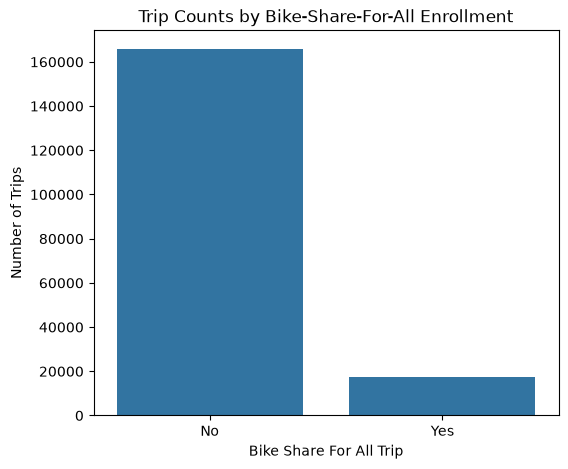

In [49]:
plt.figure(figsize=(6, 5))
sns.countplot(data=cleaned_rides_df, x='bike_share_for_all_trip', color=sns.color_palette()[0])
plt.xlabel('Bike Share For All Trip')
plt.ylabel('Number of Trips')
plt.title('Trip Counts by Bike-Share-For-All Enrollment');

**Observation:** Only a small share of trips (about 9.5%) are flagged as part of the bike-share-for-all program; the large majority of riders are not enrolled in it.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> Trip duration (`duration_sec`/`duration_min`) is extremely right-skewed — most trips are a handful of minutes, but a small number stretch out to 20+ hours. I applied a log scale to the x-axis when plotting duration so the shape of the bulk of the distribution is visible instead of being compressed into the first bin. I also derived `duration_min` from `duration_sec` for a more human-readable unit.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> `member_birth_year` contained clear data-entry errors: the raw values implied ages up to 141 years old. I converted birth year into `age` and removed rows where age exceeded 80 (192 rows, ~0.1% of the data), since these are almost certainly incorrect self-reported birth years rather than genuine outliers to be studied. I also converted `start_time`/`end_time` to proper datetimes and derived `start_hour`, `start_dow`, and `is_weekend` from them, since the raw timestamp strings aren't directly usable for time-of-day/day-of-week analysis.

## Bivariate Exploration

> In this section I look at relationships between pairs of variables that were introduced in the univariate section above: trip duration, user type, age, gender, and day-of-week/hour timing.

**Question:** Is trip duration related to rider age?

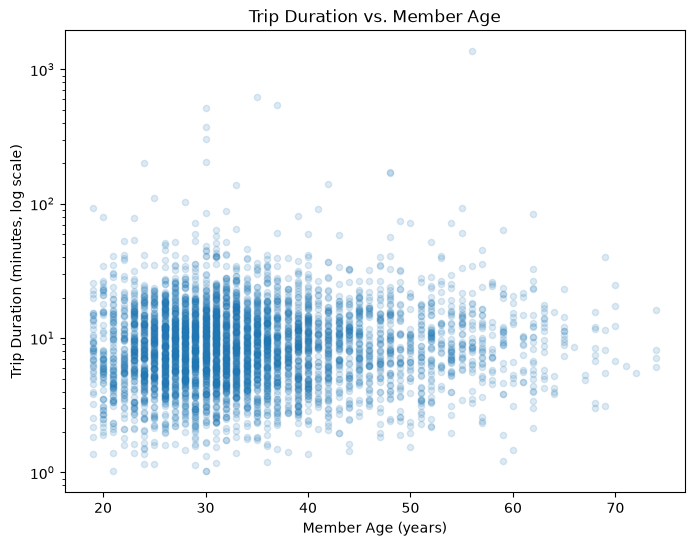

In [50]:
sample = cleaned_rides_df.sample(5000, random_state=42)

ax = sample.plot.scatter(x='age', y='duration_min', alpha=0.15, figsize=(8, 6))
ax.set_yscale('log')
ax.set_xlabel('Member Age (years)')
ax.set_ylabel('Trip Duration (minutes, log scale)')
ax.set_title('Trip Duration vs. Member Age');

In [51]:
cleaned_rides_df[['age', 'duration_min']].corr()

,age,duration_min
age,1.000000,0.007224
duration_min,0.007224,1.000000


**Observation:** There's essentially no linear relationship between age and trip duration (correlation ≈ 0.007) — riders of all ages take mostly short trips, with the occasional long outlier scattered fairly evenly across ages. Age doesn't appear to be a useful predictor of duration on its own.

**Question:** Do `Subscriber`s and `Customer`s take trips of different lengths?

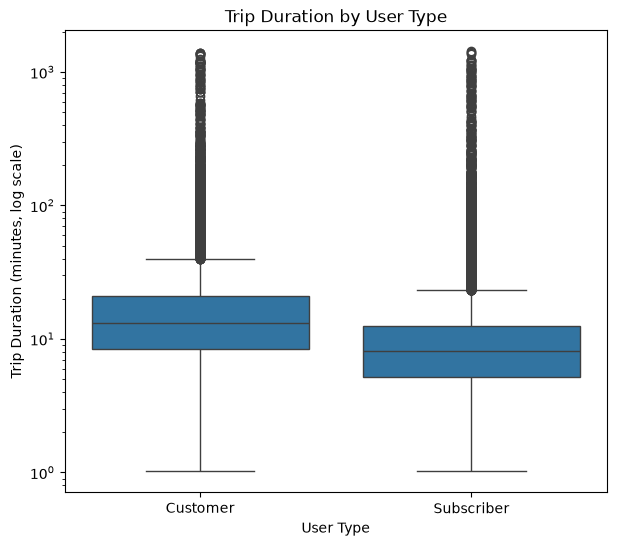

In [52]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=cleaned_rides_df, x='user_type', y='duration_min', color=sns.color_palette()[0])
plt.yscale('log')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes, log scale)')
plt.title('Trip Duration by User Type');

In [53]:
cleaned_rides_df.groupby('user_type', observed=True)['duration_min'].median()

user_type
Customer      13.200000
Subscriber     8.183333
Name: duration_min, dtype: float64

**Observation:** `Customer`s take noticeably longer trips (median ≈ 13.2 minutes) than `Subscriber`s (median ≈ 8.2 minutes), and have a visibly wider spread with more/longer outliers. This is consistent with `Subscriber`s using the bikes for quick, direct commute trips, while `Customer`s (casual/one-off riders, e.g. tourists) take more leisurely, exploratory rides.

**Question:** Does rider age differ between `Subscriber`s and `Customer`s?

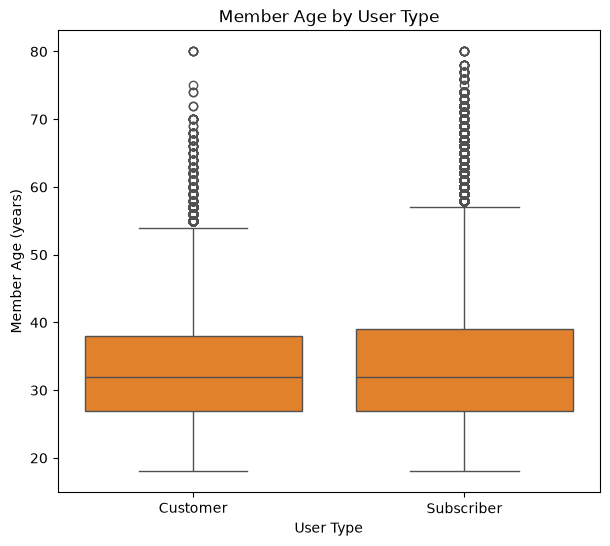

In [54]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=cleaned_rides_df, x='user_type', y='age', color=sns.color_palette()[1])
plt.xlabel('User Type')
plt.ylabel('Member Age (years)')
plt.title('Member Age by User Type');

**Observation:** The age distributions for `Subscriber`s and `Customer`s are nearly identical (median age 32 for both), so unlike duration, age doesn't distinguish the two user types.

**Question:** When during the week/day do trips happen?

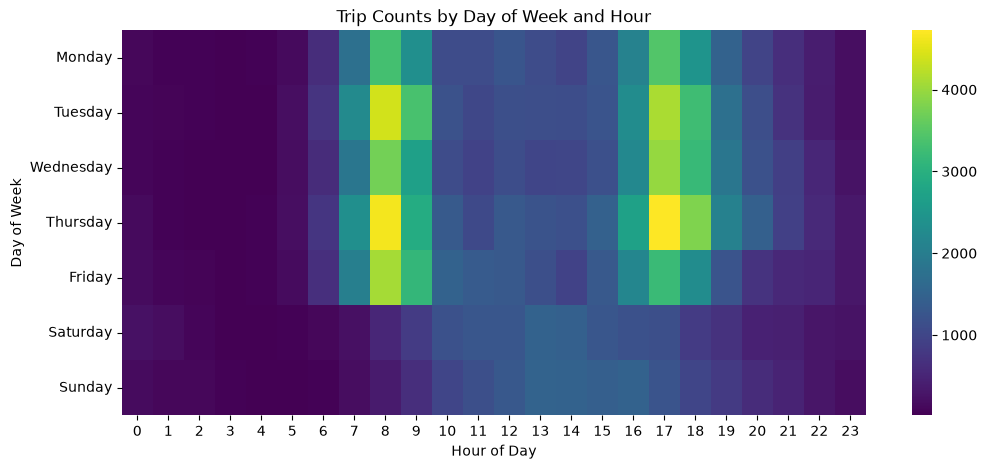

In [55]:
heat_data = cleaned_rides_df.groupby(['start_dow', 'start_hour'], observed=True).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
sns.heatmap(heat_data, cmap='viridis')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Trip Counts by Day of Week and Hour');

**Observation:** A clear commute pattern emerges: on weekdays there are two sharp peaks, around 8-9 AM and 5-6 PM, with much lower activity in between and overnight. On Saturday and Sunday, this double-peak disappears entirely in favor of a flatter, mid-day-weighted pattern. This is strong evidence that most weekday trips are commute-driven.

**Question:** Does the gender mix differ between `Subscriber`s and `Customer`s?

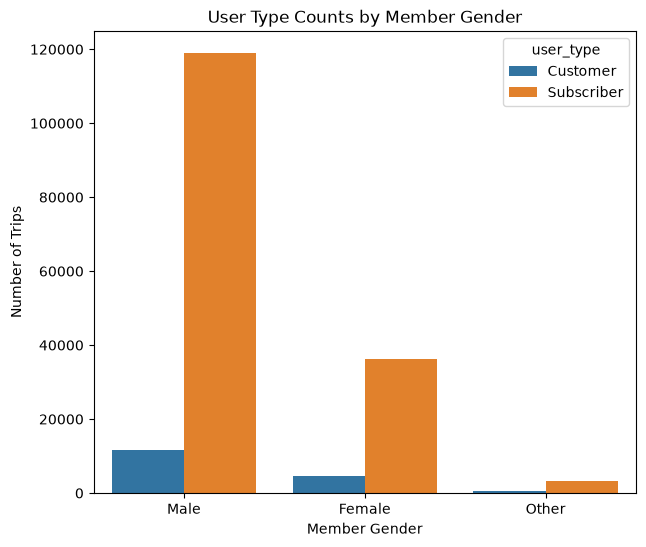

In [56]:
plt.figure(figsize=(7, 6))
sns.countplot(data=cleaned_rides_df, x='member_gender', hue='user_type', order=['Male', 'Female', 'Other'])
plt.xlabel('Member Gender')
plt.ylabel('Number of Trips')
plt.title('User Type Counts by Member Gender');

**Observation:** Across all three reported gender categories, `Subscriber` trips outnumber `Customer` trips by a wide margin, and the overall Male > Female > Other ordering holds within both user types — i.e., there's no strong interaction here, gender and user-type proportions look broadly consistent with each other.

**Question:** Which stations see the most activity, and what does that suggest about how the system is used?

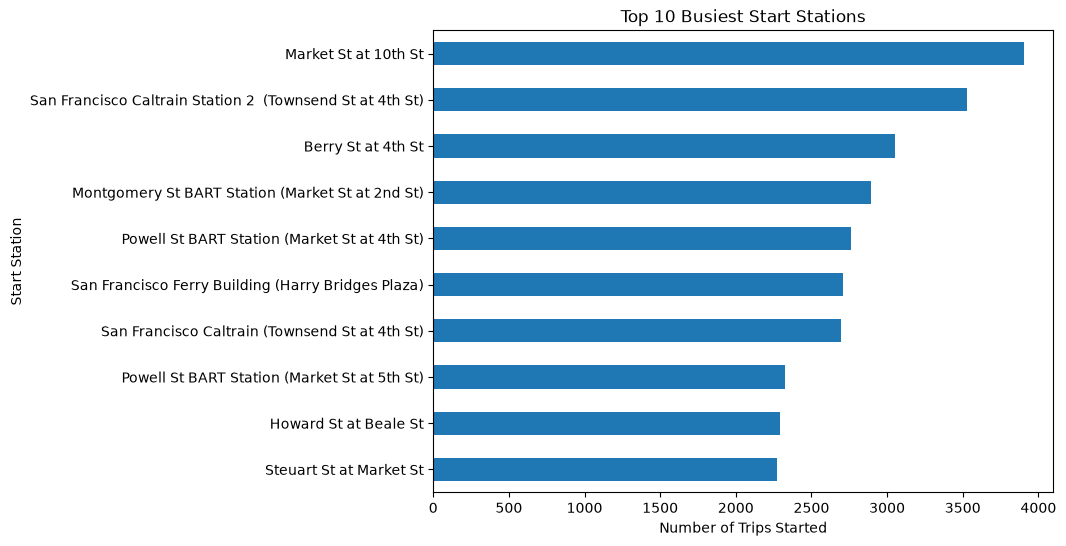

In [57]:
top_stations = cleaned_rides_df['start_station_name'].value_counts().head(10)

ax = top_stations.sort_values().plot.barh(figsize=(8, 6), color=sns.color_palette()[0])
ax.set_xlabel('Number of Trips Started')
ax.set_ylabel('Start Station')
ax.set_title('Top 10 Busiest Start Stations');

**Observation:** Several of the busiest start stations are named after or located at major regional transit hubs — Caltrain and BART stations, and the Ferry Building. This supports the idea that a large share of trips are "last-mile" connections extending a rider's commute from a transit stop to their final destination, reinforcing the commute-driven pattern seen in the day/hour heatmap.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Trip duration is where the interesting relationships show up: `Customer`s ride noticeably longer than `Subscriber`s, while age has essentially no relationship with duration. Timing (day of week and hour) shows the clearest pattern of all — a strong weekday double-peak around commute hours that disappears on weekends — and this pairs naturally with the busiest stations being transit hubs.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Age doesn't differ meaningfully between `Subscriber`s and `Customer`s, even though duration and (implicitly) trip purpose do — so the two user types are riders of similar ages simply using the service differently. The gender split also stays broadly proportional across user types rather than showing a distinct pattern.

## Multivariate Exploration

> Building on the bivariate findings — the weekday/weekend timing split and the `Subscriber`/`Customer` duration gap — I now look at three or more variables together to see how these patterns interact.

**Question:** Does the weekday commute pattern in trip *volume* hold for both user types, or is it specific to one?

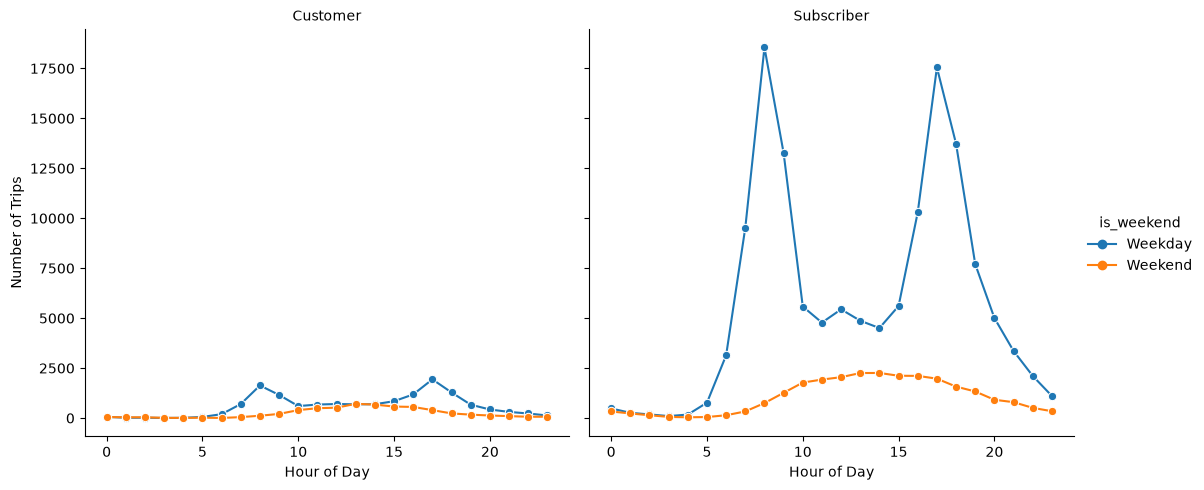

In [58]:
hourly_counts = (cleaned_rides_df
                 .groupby(['start_hour', 'user_type', 'is_weekend'], observed=True)
                 .size()
                 .reset_index(name='count'))

g = sns.relplot(data=hourly_counts, x='start_hour', y='count', hue='is_weekend',
               col='user_type', kind='line', height=5, aspect=1.1, marker='o')
g.set_axis_labels('Hour of Day', 'Number of Trips')
g.set_titles('{col_name}');

**Observation:** The weekday double-peak commute pattern is almost entirely a `Subscriber` phenomenon — `Subscriber` weekday trips show sharp spikes at 8 AM and 5-6 PM that are completely absent on `Subscriber` weekends. `Customer` trips, by contrast, stay low and relatively flat across all hours regardless of weekday/weekend, with only a mild afternoon bump. This confirms that `Subscriber`s are the commuters, while `Customer`s ride in a way that doesn't depend much on the day of the week.

**Question:** Does the `Customer` vs. `Subscriber` duration gap seen earlier hold consistently across the day, and does it change on weekends?

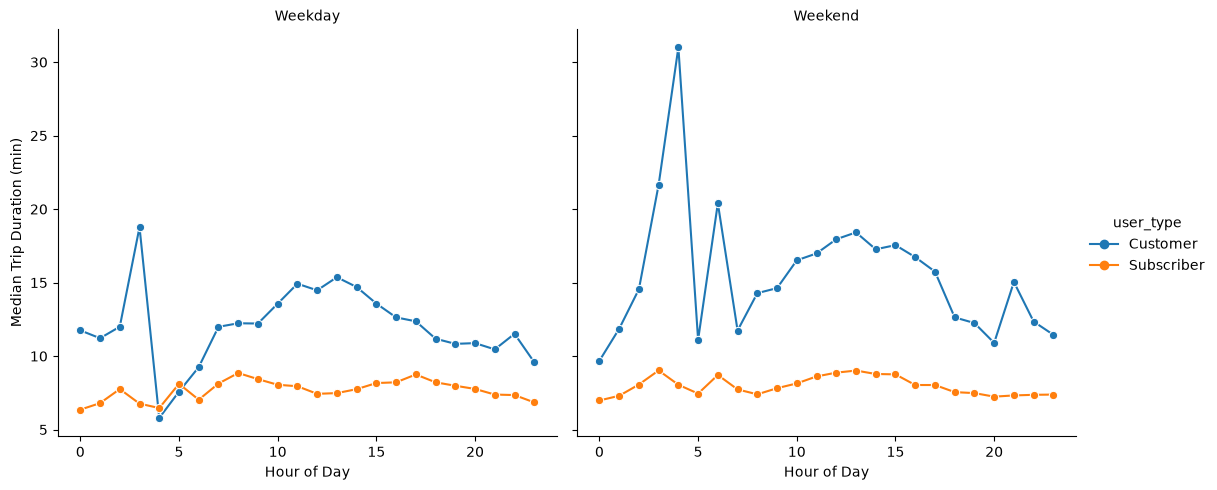

In [59]:
med_duration = (cleaned_rides_df
                 .groupby(['start_hour', 'user_type', 'is_weekend'], observed=True)['duration_min']
                 .median()
                 .reset_index())

g = sns.relplot(data=med_duration, x='start_hour', y='duration_min', hue='user_type',
               col='is_weekend', kind='line', height=5, aspect=1.1, marker='o')
g.set_axis_labels('Hour of Day', 'Median Trip Duration (min)')
g.set_titles('{col_name}');

**Observation:** `Subscriber` median duration stays low (roughly 6-9 minutes) and nearly flat across every hour on both weekdays and weekends — consistent with short, purposeful trips regardless of when they happen. `Customer` median duration is higher throughout and far more variable, and on weekends it spikes sharply in the very early morning hours (likely a small number of long overnight/leisure rides skewing the median in a low-volume period). This shows the `Subscriber`/`Customer` duration gap isn't just a one-off average — it holds up across almost every hour of the day.

**Question:** How do age, duration, user type, and gender relate to each other simultaneously?

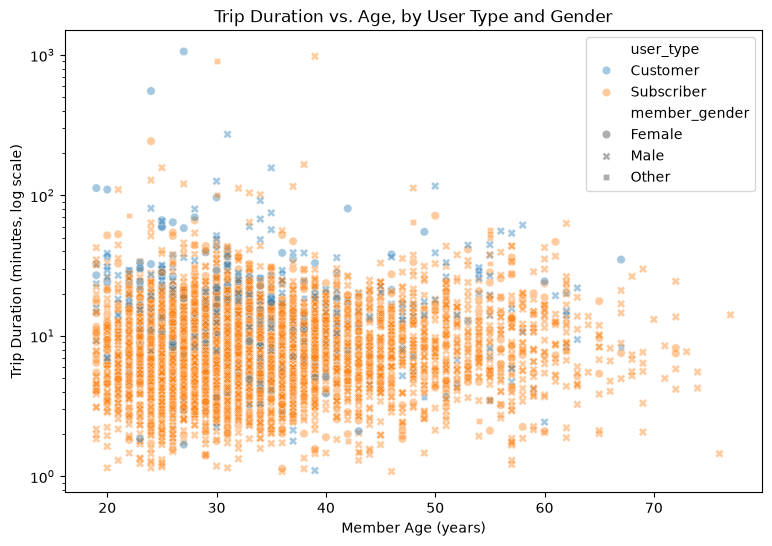

In [60]:
sample = cleaned_rides_df.sample(6000, random_state=1)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x='age', y='duration_min', hue='user_type', style='member_gender', alpha=0.4)
plt.yscale('log')
plt.xlabel('Member Age (years)')
plt.ylabel('Trip Duration (minutes, log scale)')
plt.title('Trip Duration vs. Age, by User Type and Gender');

**Observation:** Layering gender and user type onto the age/duration scatter doesn't reveal a new interaction: `Subscriber` (blue) points dominate the whole age range and sit consistently lower than the sparser `Customer` (orange) points, but this split is uniform across ages and across gender markers — there's no age range or gender where the pattern reverses or looks noticeably different. This reinforces that user type, not age or gender, is what actually drives duration.

**Question:** Looking at duration, age, and hour together, is there any joint structure a single pairwise view would miss?

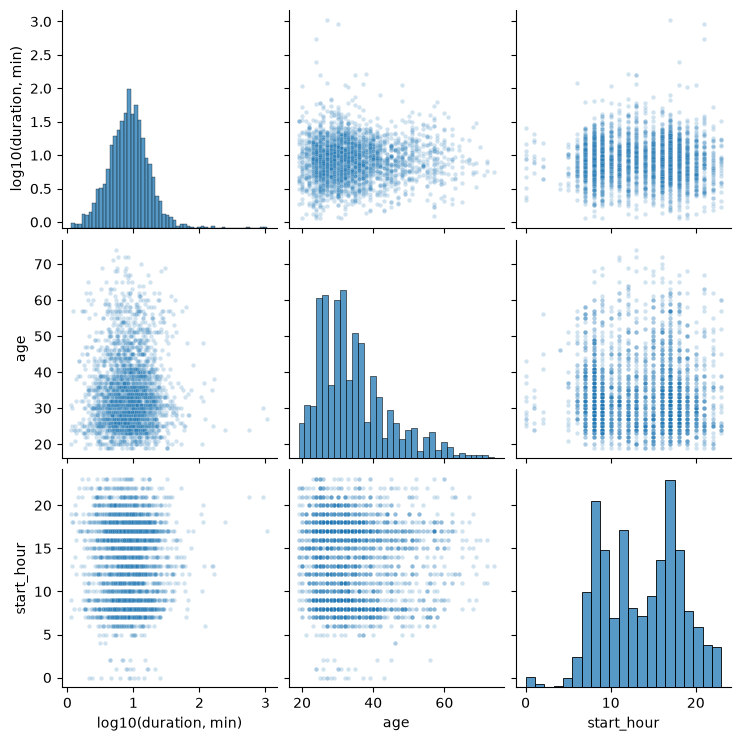

In [61]:
cleaned_rides_df['log_duration_min'] = np.log10(cleaned_rides_df['duration_min'])

num_cols = ['log_duration_min', 'age', 'start_hour']
sample = cleaned_rides_df[num_cols].sample(3000, random_state=1).dropna()

g = sns.pairplot(sample, diag_kind='hist', plot_kws={'alpha': 0.2, 's': 10})
g.axes[2][0].set_xlabel('log10(duration, min)')
g.axes[2][1].set_xlabel('age')
g.axes[2][2].set_xlabel('start_hour')
g.axes[0][0].set_ylabel('log10(duration, min)')
g.axes[1][0].set_ylabel('age')
g.axes[2][0].set_ylabel('start_hour');

**Observation:** The `start_hour` histogram on the diagonal is clearly bimodal (peaks around the commute hours identified earlier), while `log_duration` is roughly bell-shaped once log-transformed and `age` is right-skewed as seen before. None of the pairwise scatter panels show a strong linear or curved relationship — duration, age, and hour each carry mostly independent information, which matches the earlier finding that `user_type` (a categorical variable not shown here) is the stronger driver of duration rather than any of these numeric features.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> Splitting the hourly trip-volume pattern by user type showed that the weekday commute double-peak is really a `Subscriber`-specific signature, not a system-wide one — `Customer` volume stays low and flat regardless of day. Duration told a similar story: the `Subscriber`/`Customer` gap holds up consistently hour-by-hour and across weekdays/weekends, rather than being an artifact of averaging over the whole day.

### Were there any interesting or surprising interactions between features?

> The main "non-finding" here is itself informative: age and gender, layered onto the duration/user-type relationship, don't interact with it in any visible way — the `Subscriber` vs. `Customer` duration gap holds uniformly across ages and genders. That's a useful negative result: `user_type` (a proxy for commute vs. casual use) is doing essentially all the explanatory work for trip duration among the variables explored here, while age, gender, and hour behave largely independently of one another.

## Conclusions

**Summary of main findings:**
- Trip duration is heavily right-skewed: most trips last under ~13 minutes, but a long tail stretches out to over 20 hours (almost certainly a mix of genuine leisure use and unreturned/lost bikes).
- The system is overwhelmingly used by `Subscriber`s (~89% of trips), who ride shorter (median ~8 min) and follow a sharp weekday commute pattern — two volume peaks around 8-9 AM and 5-6 PM that vanish on weekends.
- `Customer`s (~11% of trips) ride longer (median ~13 min) and at a much flatter, more weekend-tolerant pace, consistent with casual/leisure or tourist use rather than commuting.
- The busiest start stations are concentrated around major transit hubs (Caltrain, BART, the Ferry Building), reinforcing that a large share of trips are last-mile commute connections.
- Member age (median 32) and gender (about 71% male, 22% female, and a small remainder of "Other" among reported values) don't meaningfully interact with the duration or user-type patterns — `user_type` is the feature that actually explains most of the variation in trip length and timing observed in this dataset.

**Reflection on the exploration process:**
I started from single-variable distributions (duration, age, user type, day of week, gender, program enrollment), which immediately flagged two data-quality issues to handle before going further: a heavily skewed duration variable (addressed with a log scale rather than removing data) and clearly invalid ages up to 141 years old (addressed by dropping a small number of rows). Moving into bivariate exploration, the day/hour heatmap and the `user_type` duration comparison were the two most informative views, and both pointed toward the same underlying story — a commuter-driven system with a distinct casual-rider segment. The multivariate stage was mainly used to stress-test that story: layering user type onto the hourly volume and duration patterns confirmed the commute signature belongs specifically to `Subscriber`s, while adding age and gender on top of duration showed those two features don't meaningfully change the picture. Overall, the data supports a fairly clean two-segment view of usage (commuter `Subscriber`s vs. casual `Customer`s) more than it supports a story built around demographics like age or gender.